In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — IMPORTS
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import time
import random
import hashlib
import warnings
import platform
from copy import deepcopy
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, cohen_kappa_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import AutoTokenizer, AutoModel
import torchvision.models as torchvision_models

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.titlesize':  12,
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi':      100,   # screen preview
    'savefig.dpi':     300,   # publication output
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

print(f"Python    : {platform.python_version()}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")



Python    : 3.12.13
PyTorch   : 2.10.0+cu128
CUDA avail: True
GPU       : Tesla T4


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    TRAIN_PATH = "/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/single_train-00000-of-00001.parquet"
    DEV_PATH   = "/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/single_dev-00000-of-00001.parquet"
    TEST_PATH  = "/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/test-00000-of-00001.parquet"
    OUTPUT_DIR = "/kaggle/working"

    # ── Model ─────────────────────────────────────────────────────────────────
    BERT_MODEL    = "law-ai/InLegalBERT"
    MAX_SENT_LEN  = 128    # max tokens per sentence fed to BERT
    MAX_SENTENCES = 64     # max sentences retained per document
    EMBED_DIM     = 768    # BERT hidden size (fixed)
    HEATMAP_SIZE  = 64     # structural heatmap spatial resolution

    # ── BiLSTM ────────────────────────────────────────────────────────────────
    LSTM_HIDDEN  = 256
    LSTM_LAYERS  = 2
    LSTM_DROPOUT = 0.3

    # ── CNN ───────────────────────────────────────────────────────────────────
    CNN_OUT_DIM = 256      # ResNet18 projection output

    # ── Fusion & Classifier ───────────────────────────────────────────────────
    FUSION_DIM  = 512      # LSTM_HIDDEN*2 + CNN_OUT_DIM → project to this
    DROPOUT     = 0.4
    NUM_CLASSES = 2

    # ── Training ──────────────────────────────────────────────────────────────
    BATCH_SIZE   = 4
    EPOCHS       = 10
    LR           = 2e-5
    WEIGHT_DECAY = 1e-2
    WARMUP_RATIO = 0.1
    GRAD_CLIP    = 1.0

    # ── Reproducibility ───────────────────────────────────────────────────────
    SEED         = 42
    # Seeds used for multi-run significance testing (5 independent runs)
    MULTI_SEEDS  = [42, 123, 256, 789, 1024]

    # ── Device ────────────────────────────────────────────────────────────────
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print(f"Device     : {cfg.DEVICE}")
print(f"BERT model : {cfg.BERT_MODEL}")
print(f"Output dir : {cfg.OUTPUT_DIR}")

Device     : cuda
BERT model : law-ai/InLegalBERT
Output dir : /kaggle/working


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────

def seed_everything(seed: int) -> None:
    """
    Comprehensive seed fixing for full reproducibility.
    Covers Python, NumPy, PyTorch (CPU + CUDA), and CUDA conv algorithms.
    NOTE: torch.use_deterministic_algorithms(True) is intentionally omitted
          because it disables several efficient CUDA kernels needed for BERT.
          The settings below are sufficient for cross-run reproducibility on
          the same hardware. Report hardware in your paper's implementation section.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False   # critical: disables non-deterministic algo selection


seed_everything(cfg.SEED)
print(f"All seeds fixed to {cfg.SEED}.")
print(f"PYTHONHASHSEED={os.environ['PYTHONHASHSEED']}")
print(f"cudnn.deterministic={torch.backends.cudnn.deterministic}")
print(f"cudnn.benchmark    ={torch.backends.cudnn.benchmark}")


def get_dataloader_generator(seed: int) -> torch.Generator:
    """Per-DataLoader generator to ensure reproducible shuffling."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g


def seed_worker(worker_id: int) -> None:
    """Per-worker seed function for DataLoader workers."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

All seeds fixed to 42.
PYTHONHASHSEED=42
cudnn.deterministic=True
cudnn.benchmark    =False



  LOADING DATASETS
  Loaded single_train-00000-of-00001.parquet: (5082, 8)  cols=['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']
  Loaded single_dev-00000-of-00001.parquet: (2511, 8)  cols=['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']
  Loaded test-00000-of-00001.parquet: (1517, 8)  cols=['id', 'text', 'label', 'expert_1', 'expert_2', 'expert_3', 'expert_4', 'expert_5']

=======================================================  TRAIN RAW  =======================================================
Shape : (5082, 8)
Labels (counts) : {0: 3147, 1: 1935}
Labels (ratio)  : {0: 0.619, 1: 0.381}
Nulls : {'id': 0, 'text': 0, 'label': 0, 'expert_1': 5082, 'expert_2': 5082, 'expert_3': 5082, 'expert_4': 5082, 'expert_5': 5082}
Sample (text):  F. NARIMAN, J. Leave granted. In 2008, the Punjab State Water Supply Sewerage Board, Bhatinda issued numberice inviting tender for extension and augmentation of water supply, sewerage sc

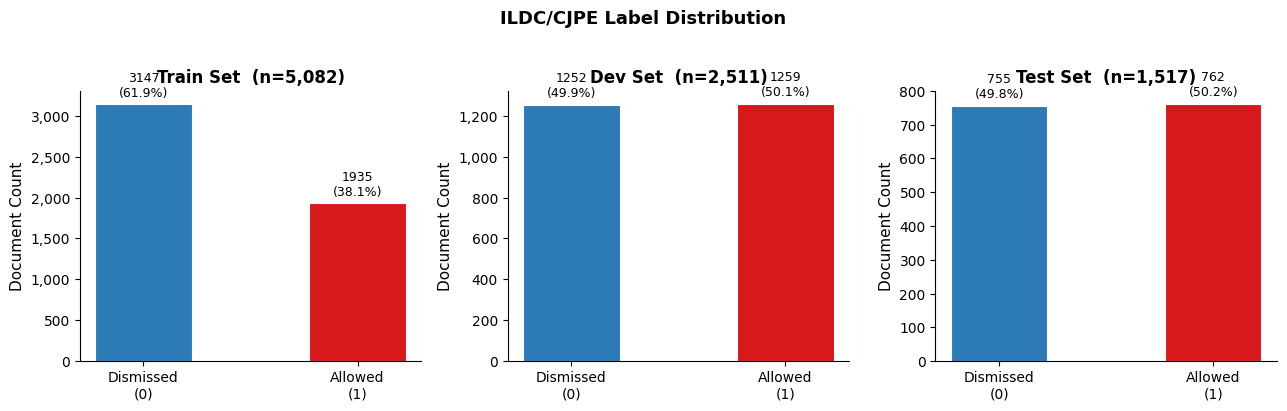

Saved: fig1_label_distribution.{pdf,png}

Class weights (balanced): [0.8074 1.3132]
Class-1 fraction in train: 0.381
Using weighted CE loss: True


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────

def load_parquet(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    print(f"  Loaded {os.path.basename(path)}: {df.shape}  cols={list(df.columns)}")
    return df


def inspect_dataset(df: pd.DataFrame, name: str = "Dataset") -> None:
    print(f"\n{'='*55}  {name}  {'='*55}")
    print(f"Shape : {df.shape}")
    if 'label' in df.columns:
        vc = df['label'].value_counts()
        vr = df['label'].value_counts(normalize=True).round(3)
        print(f"Labels (counts) : {vc.to_dict()}")
        print(f"Labels (ratio)  : {vr.to_dict()}")
    print(f"Nulls : {df.isnull().sum().to_dict()}")
    tc = 'text' if 'text' in df.columns else df.columns[0]
    print(f"Sample ({tc}): {str(df[tc].iloc[0])[:200]}")

# ── Text Cleaning ─────────────────────────────────────────────────────────────

def clean_text(text: str) -> str:
    """
    Conservative legal text cleaning.
    Preserves:  sentence-ending punctuation, parentheses, section symbols,
                forward slashes (used in case citations), percentages.
    Removes:    URLs, non-ASCII characters (common OCR noise in legal PDFs),
                runs of repeated punctuation.
    Does NOT lowercase: proper nouns and legal acronyms are case-sensitive.
    """
    if not isinstance(text, str):
        text = str(text)
    text = text.encode('ascii', 'ignore').decode('ascii')       # strip non-ASCII
    text = re.sub(r'http\S+|www\S+', '', text)                  # remove URLs
    text = re.sub(r'[^\w\s\.\,\;\:\-\(\)\%\§\'\"\/]', ' ', text)  # keep legal punctuation
    text = re.sub(r'([.!?]){2,}', r'\1', text)                  # collapse repeated punctuation
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# ── Sentence Segmentation ─────────────────────────────────────────────────────

def segment_sentences(text: str, max_sentences: int = 64) -> list:
    """
    Regex-based sentence segmenter tuned for Indian legal text.
    Splits on terminal punctuation followed by a capital letter or digit.
    Filters sentences shorter than 15 characters (likely fragment noise).
    Returns at most max_sentences sentences; falls back to full text if none found.
    """
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9])', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 15]
    sentences = sentences[:max_sentences]
    if not sentences:
        sentences = [text[:512]]
    return sentences


# ── Label Normalization ───────────────────────────────────────────────────────

def normalize_label(label) -> int:
    """Map heterogeneous label formats to binary {0: Dismissed, 1: Allowed}."""
    if isinstance(label, (int, np.integer)):
        v = int(label)
        return v if v in (0, 1) else -1
    s = str(label).strip().lower()
    if s in {'1', 'allowed', 'appeal allowed', 'accepted', 'allow'}:
        return 1
    if s in {'0', 'dismissed', 'appeal dismissed', 'rejected', 'dismiss'}:
        return 0
    return -1


def preprocess_dataframe(df: pd.DataFrame, split_name: str = "") -> pd.DataFrame:
    # ── Drop CJPE expert annotation columns if present ────────────────────────
    expert_cols = [c for c in df.columns if c.startswith('expert_')]
    if expert_cols:
        df = df.drop(columns=expert_cols)
        print(f"  [{split_name}] Dropped expert columns: {expert_cols}")

    tc = 'text'   if 'text'     in df.columns else df.columns[0]
    lc = 'label'  if 'label'    in df.columns else (
         'decision' if 'decision' in df.columns else df.columns[-1])
    print(f"  [{split_name}] text_col='{tc}'  label_col='{lc}'")

    df = df[[tc, lc]].copy()
    df.columns = ['text', 'label']
    df.dropna(subset=['text', 'label'], inplace=True)
    df['text']  = df['text'].apply(clean_text)
    df['label'] = df['label'].apply(normalize_label)
    df = df[df['label'] != -1].reset_index(drop=True)
    df['sentences'] = df['text'].apply(
        lambda t: segment_sentences(t, cfg.MAX_SENTENCES))

    cnt = Counter(df['label'].tolist())
    print(f"  [{split_name}] final shape={df.shape}  labels={dict(cnt)}")
    return df


# ── Load All Splits ───────────────────────────────────────────────────────────

print("\n" + "="*60 + "\n  LOADING DATASETS\n" + "="*60)
train_raw = load_parquet(cfg.TRAIN_PATH)
dev_raw   = load_parquet(cfg.DEV_PATH)
test_raw  = load_parquet(cfg.TEST_PATH)

inspect_dataset(train_raw, "TRAIN RAW")
inspect_dataset(dev_raw,   "DEV RAW")
inspect_dataset(test_raw,  "TEST RAW")

print("\n" + "="*60 + "\n  PREPROCESSING\n" + "="*60)
train_df = preprocess_dataframe(train_raw, "TRAIN")
dev_df   = preprocess_dataframe(dev_raw,   "DEV")
test_df  = preprocess_dataframe(test_raw,  "TEST")


# ── Label Distribution Figure (publication quality) ───────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
LABEL_NAMES = ['Dismissed\n(0)', 'Allowed\n(1)']
PALETTE     = ['#2c7bb6', '#d7191c']

for ax, (df, name) in zip(axes, [(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]):
    counts = [int((df['label'] == 0).sum()), int((df['label'] == 1).sum())]
    total  = sum(counts)
    bars   = ax.bar(LABEL_NAMES, counts, color=PALETTE, width=0.45, edgecolor='white', linewidth=0.8)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + total * 0.01,
                f'{c}\n({c/total:.1%})',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{name} Set  (n={total:,})', fontweight='bold')
    ax.set_ylabel('Document Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('ILDC/CJPE Label Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'fig1_label_distribution.pdf'),
            bbox_inches='tight')
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'fig1_label_distribution.png'),
            bbox_inches='tight')
plt.show()
print("Saved: fig1_label_distribution.{pdf,png}")


# ── Class Weights ─────────────────────────────────────────────────────────────

labels_array    = train_df['label'].values
class_weights   = compute_class_weight('balanced', classes=np.unique(labels_array), y=labels_array)
class_wt_tensor = torch.tensor(class_weights, dtype=torch.float).to(cfg.DEVICE)
imbalance_ratio = labels_array.mean()   # fraction of class-1

print(f"\nClass weights (balanced): {class_weights.round(4)}")
print(f"Class-1 fraction in train: {imbalance_ratio:.3f}")
use_class_weights = (imbalance_ratio < 0.4 or imbalance_ratio > 0.6)
print(f"Using weighted CE loss: {use_class_weights}")


In [9]:
print(train_df.columns.tolist())
train_df.head()

['text', 'label', 'sentences']


,text,label,sentences
0,"F. NARIMAN, J. Leave granted. In 2008, the Pun...",1,"[In 2008, the Punjab State Water Supply Sewera..."
1,"S. THAKUR, J. Leave granted. These appeals are...",0,[These appeals are directed against an order d...
2,"Markandey Katju, J. Leave granted. Heard learn...",1,"[Markandey Katju, J., Heard learned companynse..."
3,"ALTAMAS KABIR,J. Leave granted. The question w...",1,"[ALTAMAS KABIR,J., The question whether a Firs..."
4,"CIVIL APPEAL NO. 598 OF 2007 K. MATHUR, J. Thi...",1,"[CIVIL APPEAL NO., This appeal is directed aga..."


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — InLegalBERT SENTENCE EMBEDDINGS
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nLoading tokenizer/model: {cfg.BERT_MODEL}")
tokenizer  = AutoTokenizer.from_pretrained(cfg.BERT_MODEL)
bert_model = AutoModel.from_pretrained(cfg.BERT_MODEL).to(cfg.DEVICE)
bert_model.eval()
print("Model loaded.")


@torch.no_grad()
def embed_sentences(sentences: list,
                    tokenizer, model,
                    max_len: int  = 128,
                    batch_size: int = 32) -> np.ndarray:
    """
    Encode sentences with mean-pooling over non-padding tokens.
    Mean pooling is preferred over [CLS] for sentence-level representation
    (Reimers & Gurevych, 2019).
    Returns: np.ndarray (n_sents, 768)
    """
    all_embs = []
    for i in range(0, len(sentences), batch_size):
        batch   = sentences[i:i+batch_size]
        enc     = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt')
        enc     = {k: v.to(cfg.DEVICE) for k, v in enc.items()}
        out     = model(**enc)
        mask    = enc['attention_mask'].unsqueeze(-1).float()
        tok_emb = out.last_hidden_state
        pooled  = (tok_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        all_embs.append(pooled.cpu().numpy())
    return np.vstack(all_embs).astype(np.float32)


def precompute_and_cache(df: pd.DataFrame, cache_path: str) -> list:
    """
    Precompute sentence embeddings for all documents.
    Caches to disk so re-runs skip BERT inference (important for reproducibility:
    floating-point sums over token sequences are deterministic on the same GPU
    but may vary across hardware generations — caching eliminates this source of
    variance entirely).
    """
    if os.path.exists(cache_path):
        print(f"  Loading cached embeddings from {cache_path}")
        arr = np.load(cache_path, allow_pickle=True)
        return list(arr)

    print(f"  Computing embeddings for {len(df)} documents ...")
    t0   = time.time()
    embs = []
    for idx, row in df.iterrows():
        e = embed_sentences(row['sentences'], tokenizer, bert_model,
                            max_len=cfg.MAX_SENT_LEN)
        embs.append(e)
        if idx % 200 == 0:
            elapsed = time.time() - t0
            print(f"    {idx}/{len(df)} docs  ({elapsed:.0f}s)", end='\r')

    print(f"\n  Done in {time.time()-t0:.1f}s")
    np.save(cache_path, np.array(embs, dtype=object), allow_pickle=True)
    print(f"  Saved: {cache_path}")
    return embs


train_embs = precompute_and_cache(train_df, os.path.join(cfg.OUTPUT_DIR, 'cache_train_embs.npy'))
dev_embs   = precompute_and_cache(dev_df,   os.path.join(cfg.OUTPUT_DIR, 'cache_dev_embs.npy'))
test_embs  = precompute_and_cache(test_df,  os.path.join(cfg.OUTPUT_DIR, 'cache_test_embs.npy'))

# Free BERT from GPU memory (not needed after embedding)
del bert_model
torch.cuda.empty_cache()
print("BERT model released from GPU.")




Loading tokenizer/model: law-ai/InLegalBERT


config.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/516 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/534M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: law-ai/InLegalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/534M [00:00<?, ?B/s]

Model loaded.
  Computing embeddings for 5082 documents ...
    5000/5082 docs  (2145s)
  Done in 2176.3s
  Saved: /kaggle/working/cache_train_embs.npy
  Computing embeddings for 2511 documents ...
    2400/2511 docs  (489s)
  Done in 512.7s
  Saved: /kaggle/working/cache_dev_embs.npy
  Computing embeddings for 1517 documents ...
    1400/1517 docs  (294s)
  Done in 316.9s
  Saved: /kaggle/working/cache_test_embs.npy
BERT model released from GPU.


In [24]:
print(bert_model.config.output_attentions)

False


In [25]:
print(type(bert_model))

<class 'transformers.models.bert.modeling_bert.BertModel'>


In [26]:
print(bert_model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForPreTraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "eos_token_ids": 0,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [28]:
os.listdir(cfg.OUTPUT_DIR)

['fig3_training_curves.pdf',
 'best_dual_stream.pt',
 'abl_Sema.pt',
 'fig5_roc_curve.pdf',
 'fig5_roc_curve.png',
 'cache_test_embs.npy',
 '.virtual_documents',
 'cache_train_embs.npy',
 'cache_dev_embs.npy',
 'fig6_ablation.png',
 'fig2_structural_heatmaps.pdf',
 'fig2_structural_heatmaps.png',
 'fig1_label_distribution.png',
 'fig1_label_distribution.pdf',
 'fig4_confusion_matrix.png',
 'fig6_ablation.pdf',
 'abl_Stru.pt',
 'fig3_training_curves.png',
 'fig4_confusion_matrix.pdf']

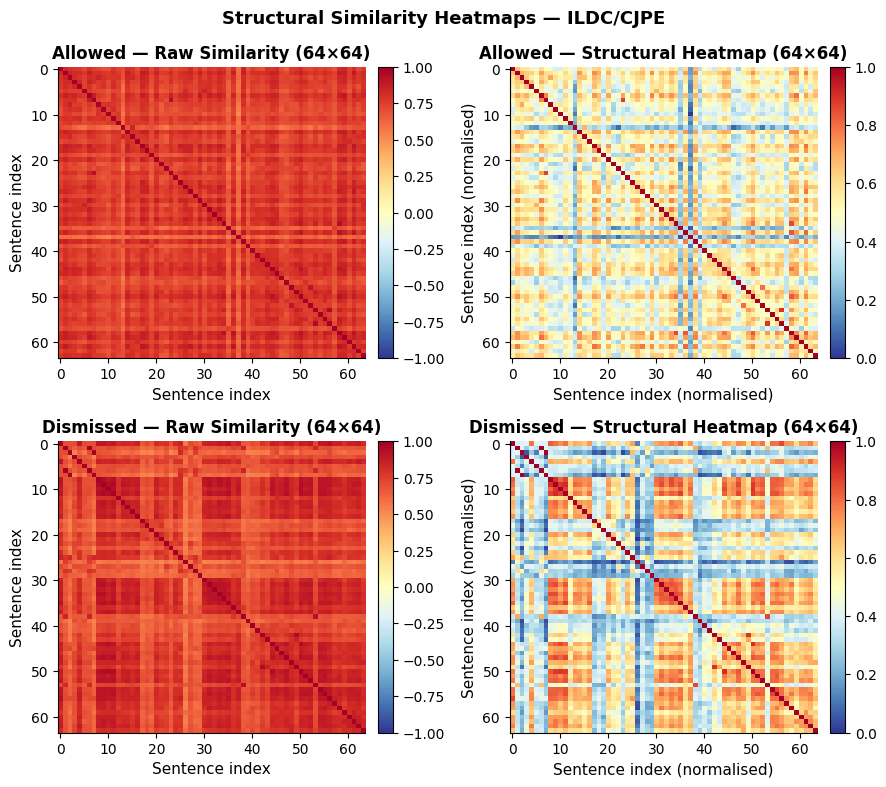

Saved: fig2_structural_heatmaps.{pdf,png}


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — STRUCTURAL HEATMAP GENERATION
# ─────────────────────────────────────────────────────────────────────────────

def build_cosine_similarity_matrix(embeddings: np.ndarray) -> np.ndarray:
    """
    Compute n×n pairwise cosine similarity matrix from sentence embeddings.
    S_ij = (e_i · e_j) / (||e_i|| ||e_j||)
    """
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    normed = embeddings / norms
    return (normed @ normed.T).astype(np.float32)


def embeddings_to_heatmap(embeddings: np.ndarray,
                           size: int = 64) -> torch.Tensor:
    """
    Convert variable-length sentence embeddings to a fixed-size structural
    heatmap image:
      1. Build cosine similarity matrix  (n × n)
      2. Bilinear resize to (size × size)
      3. Min-max normalise to [0, 1]
    Returns: torch.Tensor shape (1, size, size)  — single-channel image
    """
    sim    = build_cosine_similarity_matrix(embeddings)
    t      = torch.tensor(sim).unsqueeze(0).unsqueeze(0)   # (1,1,n,n)
    t      = F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)
    t      = t.squeeze(0)                                   # (1, size, size)
    lo, hi = t.min(), t.max()
    t      = (t - lo) / (hi - lo + 1e-9)
    return t


# ── Publication-quality heatmap figure ────────────────────────────────────────

def plot_heatmap_figure(train_embs, train_df, n_examples=3):
    """Show raw similarity matrix + resized heatmap for n_examples cases."""
    allowed_idxs  = train_df.index[train_df['label'] == 1].tolist()[:n_examples]
    dismissed_idxs = train_df.index[train_df['label'] == 0].tolist()[:n_examples]
    idxs  = allowed_idxs[:1] + dismissed_idxs[:1]
    names = ['Allowed', 'Dismissed']

    fig, axes = plt.subplots(len(idxs), 2,
                              figsize=(9, 4 * len(idxs)))

    for row, (idx, name) in enumerate(zip(idxs, names)):
        embs = train_embs[idx]
        sim  = build_cosine_similarity_matrix(embs)
        hm   = embeddings_to_heatmap(embs, cfg.HEATMAP_SIZE).squeeze().numpy()

        ax0, ax1 = (axes[row, 0], axes[row, 1]) if len(idxs) > 1 else (axes[0], axes[1])

        im0 = ax0.imshow(sim, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
        ax0.set_title(f'{name} — Raw Similarity ({len(embs)}×{len(embs)})', fontweight='bold')
        ax0.set_xlabel('Sentence index')
        ax0.set_ylabel('Sentence index')
        plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        im1 = ax1.imshow(hm, cmap='RdYlBu_r', aspect='auto')
        ax1.set_title(f'{name} — Structural Heatmap ({cfg.HEATMAP_SIZE}×{cfg.HEATMAP_SIZE})',
                      fontweight='bold')
        ax1.set_xlabel('Sentence index (normalised)')
        ax1.set_ylabel('Sentence index (normalised)')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    plt.suptitle('Structural Similarity Heatmaps — ILDC/CJPE',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'fig2_structural_heatmaps.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'fig2_structural_heatmaps.png'), bbox_inches='tight')
    plt.show()
    print("Saved: fig2_structural_heatmaps.{pdf,png}")


plot_heatmap_figure(train_embs, train_df)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — DATASET CLASS
# ─────────────────────────────────────────────────────────────────────────────

class LegalJudgmentDataset(Dataset):
    """
    Returns per sample:
      sent_embs : (MAX_SENTENCES, EMBED_DIM) — zero-padded sentence embeddings
      sent_mask : (MAX_SENTENCES,) bool       — True for valid (non-pad) positions
      heatmap   : (1, HEATMAP_SIZE, HEATMAP_SIZE) — structural similarity image
      label     : scalar int {0, 1}
    """
    def __init__(self, df, embeddings_list,
                 max_sentences=64, embed_dim=768, heatmap_size=64):
        self.df              = df.reset_index(drop=True)
        self.embeddings_list = embeddings_list
        self.max_sentences   = max_sentences
        self.embed_dim       = embed_dim
        self.heatmap_size    = heatmap_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        label = int(self.df.loc[idx, 'label'])
        embs  = self.embeddings_list[idx]         # (n, 768)
        n_use = min(len(embs), self.max_sentences)

        # Sentence embeddings (zero-padded)
        sent_t = torch.zeros(self.max_sentences, self.embed_dim, dtype=torch.float32)
        sent_t[:n_use] = torch.from_numpy(embs[:n_use])

        # Attention mask
        mask = torch.zeros(self.max_sentences, dtype=torch.bool)
        mask[:n_use] = True

        # Structural heatmap
        heatmap = embeddings_to_heatmap(embs[:n_use], self.heatmap_size)

        return {
            'sent_embs': sent_t,
            'sent_mask': mask,
            'heatmap':   heatmap,
            'label':     torch.tensor(label, dtype=torch.long),
        }


def make_loader(dataset, batch_size, shuffle, seed):
    return DataLoader(
        dataset,
        batch_size       = batch_size,
        shuffle          = shuffle,
        num_workers      = 2,
        pin_memory       = True,
        worker_init_fn   = seed_worker,
        generator        = get_dataloader_generator(seed),
    )


train_ds = LegalJudgmentDataset(train_df, train_embs,
                                 cfg.MAX_SENTENCES, cfg.EMBED_DIM, cfg.HEATMAP_SIZE)
dev_ds   = LegalJudgmentDataset(dev_df,   dev_embs,
                                 cfg.MAX_SENTENCES, cfg.EMBED_DIM, cfg.HEATMAP_SIZE)
test_ds  = LegalJudgmentDataset(test_df,  test_embs,
                                 cfg.MAX_SENTENCES, cfg.EMBED_DIM, cfg.HEATMAP_SIZE)

train_loader = make_loader(train_ds, cfg.BATCH_SIZE, shuffle=True,  seed=cfg.SEED)
dev_loader   = make_loader(dev_ds,   cfg.BATCH_SIZE, shuffle=False, seed=cfg.SEED)
test_loader  = make_loader(test_ds,  cfg.BATCH_SIZE, shuffle=False, seed=cfg.SEED)

print(f"Loaders → train={len(train_loader)}  dev={len(dev_loader)}  test={len(test_loader)}")


Loaders → train=1271  dev=628  test=380


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

# ── Bahdanau Additive Attention ───────────────────────────────────────────────

class SentenceAttention(nn.Module):
    """
    Additive (Bahdanau-style) attention over a sentence sequence.
    Learns a scalar importance weight per sentence; masked softmax ensures
    padding positions do not contribute.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor = None):
        """
        x    : (B, T, H)
        mask : (B, T) bool  — True = valid position
        Returns: context (B, H), weights (B, T)
        """
        scores = self.proj(x).squeeze(-1)                  # (B, T)
        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))
        weights = torch.softmax(scores, dim=-1)            # (B, T)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)  # (B, H)
        return context, weights


# ── Branch A — Semantic (BiLSTM + Attention) ──────────────────────────────────

class SemanticBranch(nn.Module):
    """
    Semantic branch: BiLSTM over sentence-level embeddings,
    followed by additive attention pooling.
    Input  : (B, MAX_SENT, 768)
    Output : semantic_vec (B, LSTM_HIDDEN*2),  attn_weights (B, MAX_SENT)
    """
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size   = input_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0.0,
        )
        self.drop      = nn.Dropout(dropout)
        self.attention = SentenceAttention(hidden_dim * 2)
        self.out_dim   = hidden_dim * 2

    def forward(self, x, mask=None):
        out, _          = self.bilstm(x)          # (B, T, H*2)
        out             = self.drop(out)
        context, weights = self.attention(out, mask)
        return context, weights


# ── Branch B — Structural (ResNet18 CNN on heatmap) ───────────────────────────

class StructuralBranch(nn.Module):
    """
    Structural branch: ResNet18 CNN adapted for single-channel (grayscale)
    input (the cosine similarity heatmap image).
    The first convolution weights are initialised from the mean of the
    original RGB weights to retain pretrained features.
    Input  : (B, 1, HEATMAP_SIZE, HEATMAP_SIZE)
    Output : structural_vec (B, out_dim)
    """
    def __init__(self, out_dim=256):
        super().__init__()
        resnet = torchvision_models.resnet18(pretrained=True)

        # Adapt conv1: RGB (3ch) → grayscale (1ch)
        orig_conv        = resnet.conv1
        resnet.conv1     = nn.Conv2d(1, 64,
                                     kernel_size=orig_conv.kernel_size,
                                     stride=orig_conv.stride,
                                     padding=orig_conv.padding,
                                     bias=False)
        with torch.no_grad():
            resnet.conv1.weight = nn.Parameter(
                orig_conv.weight.mean(dim=1, keepdim=True))

        # Strip the final FC; keep up through AdaptiveAvgPool
        self.features  = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        self.out_dim = out_dim

    def forward(self, x):
        feat = self.features(x)     # (B, 512, 1, 1)
        return self.projector(feat) # (B, out_dim)


# ── Full Dual-Stream Model ────────────────────────────────────────────────────

class DualStreamLegalModel(nn.Module):
    """
    Dual-Stream Semantic-Structural Framework for Indian Legal Judgment Prediction.

    Stream A (Semantic)   : InLegalBERT embeddings → BiLSTM → Additive Attention
    Stream B (Structural) : Cosine-similarity heatmap → ResNet18 CNN
    Fusion                : Concatenation → 2-layer MLP → Softmax
    """
    def __init__(self, cfg):
        super().__init__()
        self.semantic_branch   = SemanticBranch(cfg.EMBED_DIM,
                                                cfg.LSTM_HIDDEN,
                                                cfg.LSTM_LAYERS,
                                                cfg.LSTM_DROPOUT)
        self.structural_branch = StructuralBranch(cfg.CNN_OUT_DIM)

        fuse_in = self.semantic_branch.out_dim + self.structural_branch.out_dim  # 512 + 256 = 768

        self.fusion = nn.Sequential(
            nn.Linear(fuse_in,      cfg.FUSION_DIM),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(cfg.FUSION_DIM, cfg.FUSION_DIM // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
        )
        self.classifier = nn.Linear(cfg.FUSION_DIM // 2, cfg.NUM_CLASSES)

    def forward(self, sent_embs, sent_mask, heatmap):
        sem_vec, attn = self.semantic_branch(sent_embs, sent_mask)
        str_vec       = self.structural_branch(heatmap)
        fused         = torch.cat([sem_vec, str_vec], dim=-1)
        fused         = self.fusion(fused)
        logits        = self.classifier(fused)
        return logits, attn


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# ── Ablation model variants ───────────────────────────────────────────────────

class SemanticOnlyModel(nn.Module):
    """Ablation A: Semantic branch only (no structural heatmap CNN)."""
    def __init__(self, cfg):
        super().__init__()
        self.branch = SemanticBranch(cfg.EMBED_DIM, cfg.LSTM_HIDDEN,
                                     cfg.LSTM_LAYERS, cfg.LSTM_DROPOUT)
        self.head = nn.Sequential(
            nn.Linear(self.branch.out_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(256, cfg.NUM_CLASSES),
        )

    def forward(self, sent_embs, sent_mask, heatmap=None):
        v, attn = self.branch(sent_embs, sent_mask)
        return self.head(v), attn


class StructuralOnlyModel(nn.Module):
    """Ablation B: Structural branch only (no BiLSTM semantic stream)."""
    def __init__(self, cfg):
        super().__init__()
        self.branch = StructuralBranch(cfg.CNN_OUT_DIM)
        self.head = nn.Sequential(
            nn.Linear(cfg.CNN_OUT_DIM, 128), nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(128, cfg.NUM_CLASSES),
        )

    def forward(self, sent_embs=None, sent_mask=None, heatmap=None):
        v = self.branch(heatmap)
        return self.head(v), None


# Instantiate and inspect main model
seed_everything(cfg.SEED)
model = DualStreamLegalModel(cfg).to(cfg.DEVICE)
total_p, train_p = count_parameters(model)
print(f"\nDualStreamLegalModel")
print(f"  Total parameters     : {total_p:,}")
print(f"  Trainable parameters : {train_p:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s] 



DualStreamLegalModel
  Total parameters     : 15,505,859
  Trainable parameters : 15,505,859


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — TRAINING & EVALUATION UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def build_optimizer_and_schedulers(model, cfg, n_batches):
    optimizer     = AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    total_steps   = n_batches * cfg.EPOCHS
    warmup_steps  = int(total_steps * cfg.WARMUP_RATIO)
    warmup_sched  = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda s: float(s) / max(1, warmup_steps) if s < warmup_steps else 1.0,
    )
    main_sched    = CosineAnnealingLR(optimizer,
                                       T_max=max(1, total_steps - warmup_steps),
                                       eta_min=1e-7)
    return optimizer, warmup_sched, main_sched, warmup_steps


def train_epoch(model, loader, optimizer, criterion, device,
                grad_clip, global_step, warmup_steps,
                warmup_sched, main_sched):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []

    for batch in loader:
        se   = batch['sent_embs'].to(device)
        sm   = batch['sent_mask'].to(device)
        hm   = batch['heatmap'].to(device)
        labs = batch['label'].to(device)

        optimizer.zero_grad()
        logits, _ = model(se, sm, hm)
        loss      = criterion(logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        global_step += 1
        if global_step <= warmup_steps:
            warmup_sched.step()
        else:
            main_sched.step()

        total_loss  += loss.item()
        preds_all.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        labels_all.extend(labs.cpu().numpy())

    n     = len(loader)
    acc   = accuracy_score(labels_all, preds_all)
    f1    = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return total_loss / n, acc, f1, global_step


@torch.no_grad()
def evaluate_full(model, loader, criterion, device):
    """
    Full evaluation returning all scalar metrics plus raw predictions/labels
    (needed for McNemar's test and ROC curve).
    """
    model.eval()
    total_loss, preds_all, labels_all, probs_all = 0.0, [], [], []

    for batch in loader:
        se   = batch['sent_embs'].to(device)
        sm   = batch['sent_mask'].to(device)
        hm   = batch['heatmap'].to(device)
        labs = batch['label'].to(device)

        logits, _ = model(se, sm, hm)
        loss      = criterion(logits, labs)

        total_loss  += loss.item()
        probs        = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds_all.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        labels_all.extend(labs.cpu().numpy())
        probs_all.extend(probs)

    y_true  = np.array(labels_all)
    y_pred  = np.array(preds_all)
    y_prob  = np.array(probs_all)

    metrics = {
        'loss'     : total_loss / len(loader),
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred,    average='macro', zero_division=0),
        'f1_macro' : f1_score(y_true, y_pred,        average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred,      average='weighted', zero_division=0),
        'kappa'    : cohen_kappa_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_prob),
    }
    return metrics, y_pred, y_true, y_prob


def train_model(model, train_loader, dev_loader, cfg, criterion,
                verbose=True, model_save_path='best_model.pt'):
    """Full training loop. Returns best dev F1, history, and best predictions."""
    optimizer, warmup_sched, main_sched, warmup_steps = \
        build_optimizer_and_schedulers(model, cfg, len(train_loader))

    history     = {k: [] for k in ['train_loss','train_acc','train_f1',
                                     'dev_loss','dev_acc','dev_f1','dev_kappa','dev_auc']}
    best_f1     = 0.0
    global_step = 0

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, tr_acc, tr_f1, global_step = train_epoch(
            model, train_loader, optimizer, criterion, cfg.DEVICE,
            cfg.GRAD_CLIP, global_step, warmup_steps, warmup_sched, main_sched)

        dev_metrics, _, _, _ = evaluate_full(model, dev_loader, criterion, cfg.DEVICE)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['train_f1'].append(tr_f1)
        history['dev_loss'].append(dev_metrics['loss'])
        history['dev_acc'].append(dev_metrics['accuracy'])
        history['dev_f1'].append(dev_metrics['f1_macro'])
        history['dev_kappa'].append(dev_metrics['kappa'])
        history['dev_auc'].append(dev_metrics['roc_auc'])

        if verbose:
            print(f"  Ep {epoch:02d}  "
                  f"tr_loss={tr_loss:.4f}  tr_f1={tr_f1:.4f}  |  "
                  f"dev_f1={dev_metrics['f1_macro']:.4f}  "
                  f"κ={dev_metrics['kappa']:.4f}  "
                  f"AUC={dev_metrics['roc_auc']:.4f}")

        if dev_metrics['f1_macro'] > best_f1:
            best_f1 = dev_metrics['f1_macro']
            torch.save(model.state_dict(), model_save_path)

    return best_f1, history



  TRAINING: DUAL-STREAM MODEL
  Ep 01  tr_loss=0.6945  tr_f1=0.4868  |  dev_f1=0.3327  κ=0.0000  AUC=0.5226
  Ep 02  tr_loss=0.6963  tr_f1=0.4180  |  dev_f1=0.3369  κ=-0.0000  AUC=0.5142
  Ep 03  tr_loss=0.7125  tr_f1=0.4422  |  dev_f1=0.3327  κ=0.0000  AUC=0.5357
  Ep 04  tr_loss=0.7179  tr_f1=0.4766  |  dev_f1=0.4071  κ=0.0034  AUC=0.5296
  Ep 05  tr_loss=0.6816  tr_f1=0.5837  |  dev_f1=0.5292  κ=0.0585  AUC=0.5603
  Ep 06  tr_loss=0.6281  tr_f1=0.6648  |  dev_f1=0.4811  κ=0.0443  AUC=0.5435
  Ep 07  tr_loss=0.5708  tr_f1=0.7123  |  dev_f1=0.4614  κ=0.0432  AUC=0.5465
  Ep 08  tr_loss=0.5454  tr_f1=0.7335  |  dev_f1=0.4774  κ=0.0450  AUC=0.5333
  Ep 09  tr_loss=0.5128  tr_f1=0.7593  |  dev_f1=0.4869  κ=0.0562  AUC=0.5512
  Ep 10  tr_loss=0.5314  tr_f1=0.7548  |  dev_f1=0.4584  κ=0.0376  AUC=0.5421

Best Dev Macro-F1: 0.5292


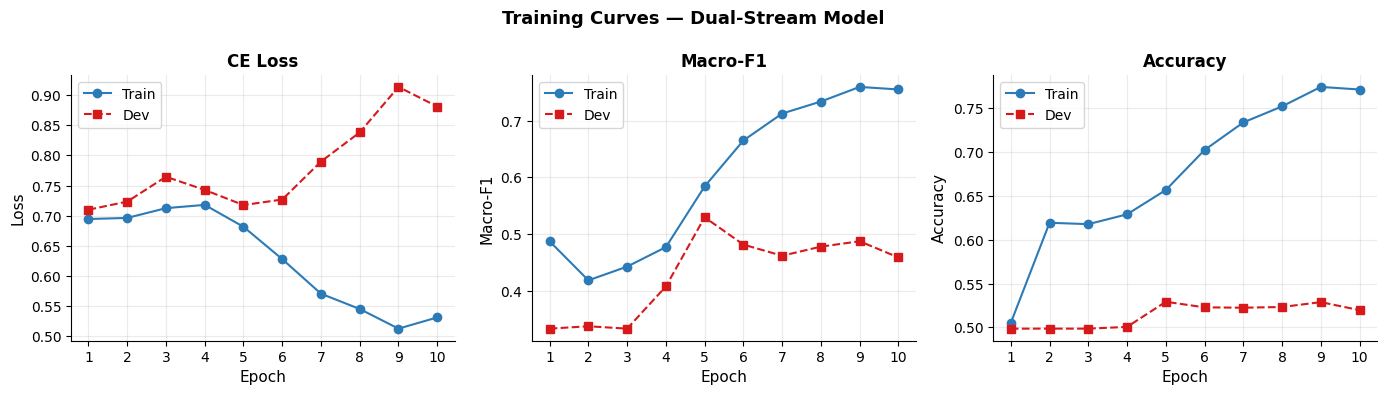

Saved: fig3_training_curves.{pdf,png}


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — MAIN TRAINING RUN
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60 + "\n  TRAINING: DUAL-STREAM MODEL\n" + "="*60)

criterion = nn.CrossEntropyLoss(
    weight=class_wt_tensor if use_class_weights else None)

seed_everything(cfg.SEED)
model = DualStreamLegalModel(cfg).to(cfg.DEVICE)

best_dev_f1, history = train_model(
    model, train_loader, dev_loader, cfg, criterion,
    verbose=True,
    model_save_path=os.path.join(cfg.OUTPUT_DIR, 'best_dual_stream.pt')
)
print(f"\nBest Dev Macro-F1: {best_dev_f1:.4f}")


# ── Training curves (publication quality) ─────────────────────────────────────

def plot_training_curves(history, save_prefix='fig3_training_curves'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    specs = [
        ('train_loss', 'dev_loss',  'CE Loss',    'Loss'),
        ('train_f1',   'dev_f1',    'Macro-F1',   'Macro-F1'),
        ('train_acc',  'dev_acc',   'Accuracy',   'Accuracy'),
    ]
    for ax, (tr_key, dv_key, title, ylabel) in zip(axes, specs):
        ax.plot(epochs, history[tr_key], 'o-',  color='#2c7bb6', label='Train', linewidth=1.5)
        ax.plot(epochs, history[dv_key], 's--', color='#d7191c', label='Dev',   linewidth=1.5)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.25)

    plt.suptitle('Training Curves — Dual-Stream Model', fontsize=13, fontweight='bold')
    plt.tight_layout()
    for ext in ['pdf', 'png']:
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'{save_prefix}.{ext}'),
                    bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_prefix}.{{pdf,png}}")


plot_training_curves(history)




  TEST SET RESULTS
  loss            : 0.7219
  accuracy        : 0.5333
  precision       : 0.5333
  recall          : 0.5332
  f1_macro        : 0.5332
  f1_weighted     : 0.5332
  kappa           : 0.0665
  roc_auc         : 0.5653

Per-Class Classification Report:
               precision    recall  f1-score   support

Dismissed (0)     0.5319    0.5192    0.5255       755
  Allowed (1)     0.5346    0.5472    0.5409       762

     accuracy                         0.5333      1517
    macro avg     0.5333    0.5332    0.5332      1517
 weighted avg     0.5333    0.5333    0.5332      1517



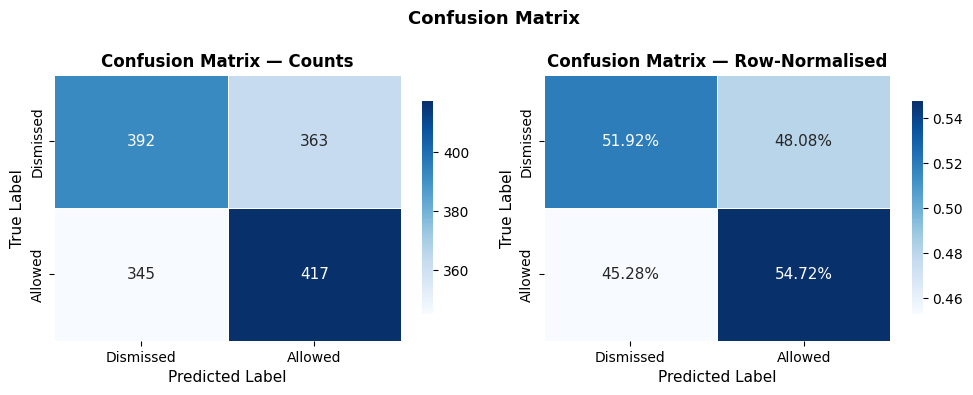

Saved: fig4_confusion_matrix.{pdf,png}


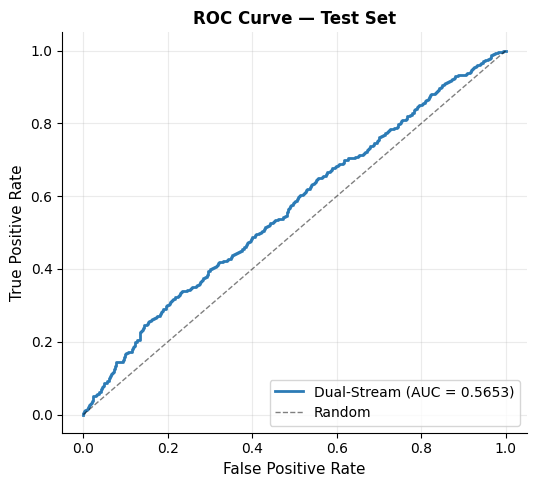

Saved: fig5_roc_curve.{pdf,png}


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — TEST EVALUATION & PUBLICATION METRICS TABLE
# ─────────────────────────────────────────────────────────────────────────────

model.load_state_dict(torch.load(
    os.path.join(cfg.OUTPUT_DIR, 'best_dual_stream.pt'),
    map_location=cfg.DEVICE))

test_metrics, test_preds, test_labels, test_probs = \
    evaluate_full(model, test_loader, criterion, cfg.DEVICE)

print("\n" + "="*60 + "\n  TEST SET RESULTS\n" + "="*60)
for k, v in test_metrics.items():
    print(f"  {k:15s} : {v:.4f}")

print("\nPer-Class Classification Report:")
print(classification_report(test_labels, test_preds,
                              target_names=['Dismissed (0)', 'Allowed (1)'],
                              digits=4))


# ── Confusion Matrix figure ───────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix',
                           save_name='fig4_confusion_matrix'):
    cm   = confusion_matrix(y_true, y_pred)
    cmn  = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, data, fmt, subtitle in zip(
            axes,
            [cm, cmn],
            ['d', '.2%'],
            ['Counts', 'Row-Normalised']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=['Dismissed', 'Allowed'],
                    yticklabels=['Dismissed', 'Allowed'],
                    ax=ax, linewidths=0.5,
                    cbar_kws={'shrink': 0.8})
        ax.set_title(f'{title} — {subtitle}', fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    for ext in ['pdf', 'png']:
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'{save_name}.{ext}'),
                    bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}.{{pdf,png}}")


plot_confusion_matrix(test_labels, test_preds)


# ── ROC Curve figure ──────────────────────────────────────────────────────────

def plot_roc_curve(y_true, y_prob, auc_score, save_name='fig5_roc_curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(fpr, tpr, color='#2c7bb6', linewidth=2,
            label=f'Dual-Stream (AUC = {auc_score:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve — Test Set', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    for ext in ['pdf', 'png']:
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'{save_name}.{ext}'),
                    bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}.{{pdf,png}}")


plot_roc_curve(test_labels, test_probs, test_metrics['roc_auc'])



In [18]:
# ── Train ablation models ────────────────────────────────────────────────

import copy

for model_name, ModelClass in ablation_registry.items():

    print(f"\n── {model_name.replace(chr(10),' ')} ──")

    seed_everything(cfg.SEED)

    m = ModelClass(cfg).to(cfg.DEVICE)

    tp, trp = count_parameters(m)
    print(f"  Parameters: {tp:,} total / {trp:,} trainable")

    # ------------------------------------------------------------------
    # Proposed model: use already-trained checkpoint
    # ------------------------------------------------------------------
    if 'Dual-Stream' in model_name:

        m.load_state_dict(
            torch.load(
                os.path.join(cfg.OUTPUT_DIR, 'best_dual_stream.pt'),
                map_location=cfg.DEVICE
            )
        )

        metrics, preds, _, probs = evaluate_full(
            m,
            test_loader,
            criterion,
            cfg.DEVICE
        )

        print("  (using fully-trained weights)")

    # ------------------------------------------------------------------
    # Train ablation variants
    # ------------------------------------------------------------------
    else:

        abl_path = os.path.join(
            cfg.OUTPUT_DIR,
            f"abl_{model_name[:4].replace(chr(10),'').strip()}.pt"
        )

        # Create a safe copy of cfg
        abl_cfg = copy.deepcopy(cfg)

        # Override epochs for faster ablation
        abl_cfg.EPOCHS = ABLATION_EPOCHS

        print(f"  LR           : {abl_cfg.LR}")
        print(f"  Epochs       : {abl_cfg.EPOCHS}")
        print(f"  Weight Decay : {abl_cfg.WEIGHT_DECAY}")

        train_model(
            model=m,
            train_loader=train_loader,
            dev_loader=dev_loader,
            cfg=abl_cfg,
            criterion=criterion,
            verbose=True,
            model_save_path=abl_path
        )

        m.load_state_dict(
            torch.load(
                abl_path,
                map_location=cfg.DEVICE
            )
        )

        metrics, preds, _, probs = evaluate_full(
            m,
            test_loader,
            criterion,
            cfg.DEVICE
        )

    ablation_results[model_name] = {
        'metrics': metrics,
        'preds': preds,
        'probs': probs,
    }

    print(
        f"  Test Macro-F1={metrics['f1_macro']:.4f}  "
        f"Acc={metrics['accuracy']:.4f}  "
        f"κ={metrics['kappa']:.4f}  "
        f"AUC={metrics['roc_auc']:.4f}"
    )


── Semantic Only (BiLSTM+Attn) ──
  Parameters: 3,810,563 total / 3,810,563 trainable
  LR           : 2e-05
  Epochs       : 5
  Weight Decay : 0.01
  Ep 01  tr_loss=0.6921  tr_f1=0.4565  |  dev_f1=0.3327  κ=0.0000  AUC=0.5781
  Ep 02  tr_loss=0.6899  tr_f1=0.4086  |  dev_f1=0.5826  κ=0.1802  AUC=0.6051
  Ep 03  tr_loss=0.6802  tr_f1=0.5620  |  dev_f1=0.5693  κ=0.1411  AUC=0.5964
  Ep 04  tr_loss=0.6701  tr_f1=0.5787  |  dev_f1=0.5722  κ=0.1452  AUC=0.5960
  Ep 05  tr_loss=0.6699  tr_f1=0.5832  |  dev_f1=0.5787  κ=0.1591  AUC=0.6030
  Test Macro-F1=0.5829  Acc=0.5906  κ=0.1823  AUC=0.6000

── Structural Only (CNN Heatmap) ──
  Parameters: 11,334,722 total / 11,334,722 trainable
  LR           : 2e-05
  Epochs       : 5
  Weight Decay : 0.01
  Ep 01  tr_loss=0.6996  tr_f1=0.5083  |  dev_f1=0.3360  κ=-0.0008  AUC=0.4994
  Ep 02  tr_loss=0.6983  tr_f1=0.4919  |  dev_f1=0.3408  κ=-0.0064  AUC=0.4908
  Ep 03  tr_loss=0.6946  tr_f1=0.5073  |  dev_f1=0.3601  κ=-0.0074  AUC=0.4777
  Ep 04  t

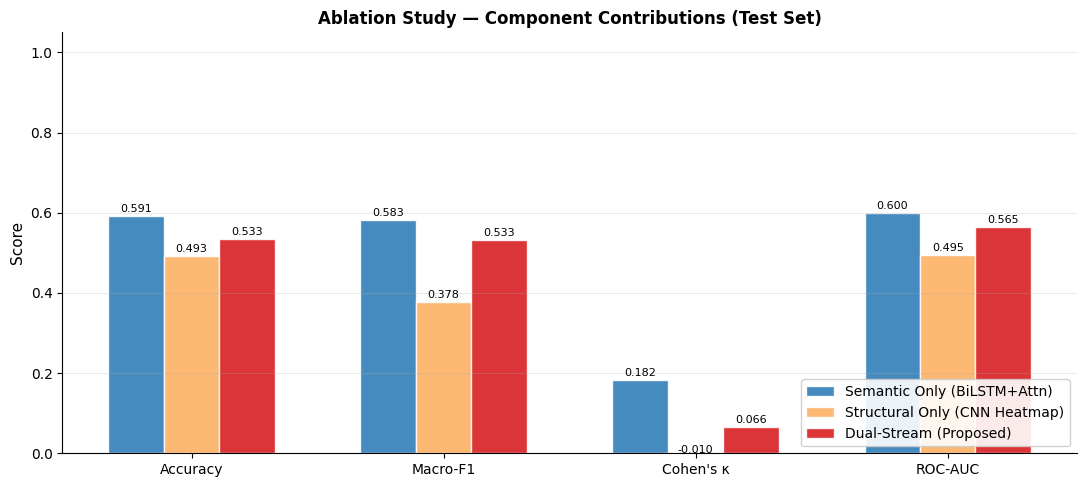

Saved: fig6_ablation.{pdf,png}

McNemar's test: Dual-Stream  vs.  Semantic Only
  Contingency table: [[580, 229], [316, 392]]
  b=229  c=316  statistic=13.5706  p-value=0.0002
  ✓ SIGNIFICANT (p<0.05)

McNemar's test: Dual-Stream  vs.  Structural Only
  Contingency table: [[399, 410], [349, 359]]
  b=410  c=349  statistic=4.7431  p-value=0.0294
  ✓ SIGNIFICANT (p<0.05)


In [20]:
def plot_ablation(ablation_results, save_name='fig6_ablation'):
    metric_keys  = ['accuracy', 'f1_macro', 'kappa', 'roc_auc']
    metric_labels= ['Accuracy', 'Macro-F1', "Cohen's κ", 'ROC-AUC']
    model_names  = list(ablation_results.keys())
    n_models     = len(model_names)
    n_metrics    = len(metric_keys)

    x     = np.arange(n_metrics)
    width = 0.22
    colors= ['#2c7bb6', '#fdae61', '#d7191c']

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (name, color) in enumerate(zip(model_names, colors)):
        vals  = [ablation_results[name]['metrics'][k] for k in metric_keys]
        bars  = ax.bar(x + (i - 1) * width, vals, width,
                       label=name.replace('\n', ' '),
                       color=color, alpha=0.88, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('Ablation Study — Component Contributions (Test Set)',
                 fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    for ext in ['pdf', 'png']:
        plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'{save_name}.{ext}'),
                    bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}.{{pdf,png}}")


plot_ablation(ablation_results)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — STATISTICAL SIGNIFICANCE (McNemar's Test)
# ─────────────────────────────────────────────────────────────────────────────
#
# McNemar's test compares two classifiers on the same test set by examining
# their disagreements. Null hypothesis: both classifiers have the same error rate.
# p < 0.05 → proposed model is significantly better than the baseline.
# Reference: McNemar (1947); Dietterich (1998) recommends this for NLP comparison.
# ─────────────────────────────────────────────────────────────────────────────

def mcnemar_test(y_true, preds_A, preds_B, name_A='A', name_B='B'):
    """
    McNemar's test between two classifiers.
    b = cases where A correct, B wrong
    c = cases where A wrong,   B correct
    """
    correct_A = (preds_A == y_true)
    correct_B = (preds_B == y_true)
    b = int(( correct_A & ~correct_B).sum())   # A right, B wrong
    c = int((~correct_A &  correct_B).sum())   # A wrong, B right

    # Build 2×2 contingency table
    table = [[int((correct_A & correct_B).sum()),  b],
             [c,  int((~correct_A & ~correct_B).sum())]]

    result  = mcnemar(table, exact=False, correction=True)  # chi-squared with Yates' correction
    print(f"\nMcNemar's test: {name_A}  vs.  {name_B}")
    print(f"  Contingency table: {table}")
    print(f"  b={b}  c={c}  statistic={result.statistic:.4f}  p-value={result.pvalue:.4f}")
    sig = "✓ SIGNIFICANT (p<0.05)" if result.pvalue < 0.05 else "✗ not significant"
    print(f"  {sig}")
    return result.pvalue


proposed_preds = ablation_results['Dual-Stream\n(Proposed)']['preds']
sem_preds      = ablation_results['Semantic Only\n(BiLSTM+Attn)']['preds']
str_preds      = ablation_results['Structural Only\n(CNN Heatmap)']['preds']

p_vs_sem = mcnemar_test(test_labels, proposed_preds, sem_preds,
                         'Dual-Stream', 'Semantic Only')
p_vs_str = mcnemar_test(test_labels, proposed_preds, str_preds,
                         'Dual-Stream', 'Structural Only')